In [1]:
from RankIC.backtest_utilts_new import *
import pandas as pd
from RankIC.efficientCalculation import EfficientCalculator
from tqdm import tqdm
from pathlib import Path


def read_factor_file(file_path):
    file_path = Path(file_path)
    if not file_path.exists():
        return None
    # 读取存储的因子数据
    if file_path.suffix == ".parquet":
        factor_df = pd.read_parquet(file_path)
    elif file_path.suffix == ".csv":
        factor_df = pd.read_csv(file_path, parse_dates=["time"])
    else:
        raise ValueError(f"不支持的文件格式{file_path}")
    return factor_df


def load_factor_long_csv(path: str) -> pd.DataFrame:
    """
    读取因子长表 CSV，要求列: time, unique_id, factor_tag, value
    返回 DataFrame，并保证 time 为 datetime、按 (unique_id, factor_tag, time) 排序。
    """
    df = pd.read_csv(path)
    required = {"time", "unique_id", "factor_tag", "value"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"因子CSV缺少必要列: {sorted(missing)}")

    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values(["unique_id", "factor_tag", "time"]).reset_index(drop=True)
    return df


# 准备因子数据
factor_df = read_factor_file("/Users/hpy/PycharmProjects/FAMA/scripts/LLM_factors/dsl_LLM_factors_new.parquet")

native_price, price_df, open_price_df, working_days = prepare_price_data(
    data_path="/Users/hpy/PycharmProjects/FAMA/data/fof_price_updating.parquet"
)

price_df = price_df.ffill().bfill()
open_price_df = open_price_df.ffill().bfill()
zz800 = price_df["000906.SH"]
tester = NMWBacktester(price_df, fee=0.0002)

pd.set_option("display.max_columns", None)
factor_df_500_1000 = factor_df[factor_df['unique_id'].isin(['000905.SH', '000852.SH'])]
# factor_df_500_1000 = factor_df

eff_calc = EfficientCalculator()

# 参数设置
need_assets = ['000905.SH', '000852.SH']  # 需要计算的资产
# need_assets = list(price_df.columns)
start_date = '2015-01-01'
end_date = '2020-12-31'

# 计算收益率（shift(-1)表示使用未来1日收益率）
asset_returns = price_df[need_assets].pct_change(1).shift(-1).dropna()

# 存储结果的列表
ric_results = []

print("开始计算RIC...")

# 筛选时间范围内的数据
factor_data = factor_df_500_1000.query(
    "time >= @start_date and time <= @end_date"
).copy()

# 按 unique_id 和 factor_tag 分组
grouped = factor_data.groupby(['unique_id', 'factor_tag'])

print(f"共有 {len(grouped)} 个 资产-因子 组合\n")

# 遍历每个组合
for (asset_id, factor_tag), group in tqdm(grouped, desc="计算RIC"):

    # 获取因子值（按时间排序）
    factor_series = group.set_index('time')['value'].sort_index()

    # 获取对应的收益率
    if asset_id not in asset_returns.columns:
        continue

    returns_series = asset_returns[asset_id]

    # 对齐数据
    common_dates = factor_series.index.intersection(returns_series.index)
    factor_aligned = factor_series.loc[common_dates]
    returns_aligned = returns_series.loc[common_dates]

    # 去除NaN
    valid_mask = ~(factor_aligned.isna() | returns_aligned.isna())
    factor_clean = factor_aligned[valid_mask]

    returns_clean = returns_aligned[valid_mask]

    # 检查样本数量
    if len(factor_clean) < 10:
        continue

    # 检查是否为常量
    if factor_clean.nunique() <= 1 or returns_clean.nunique() <= 1:
        continue

    # 计算RIC
    ric = eff_calc.efficent_cal_ric(factor_clean.values, returns_clean.values)

    if not pd.isna(ric):
        ric_results.append({
            'unique_id': asset_id,
            'factor_tag': factor_tag,
            'ric': ric,
            'sample_count': len(factor_clean),
            'start_date': factor_clean.index.min(),
            'end_date': factor_clean.index.max()
        })

# 转换为DataFrame
ric_df = pd.DataFrame(ric_results)

print(f"\n计算完成！共得到 {len(ric_df)} 个有效RIC结果")

# 按RIC绝对值排序
ric_df['abs_ric'] = ric_df['ric'].abs()
ric_df = ric_df.sort_values('abs_ric', ascending=False).reset_index(drop=True)
# 只看关键三列，去掉索引
ric_df.to_csv("/Users/hpy/PycharmProjects/FAMA/RankIC/factor_ric.csv")

开始计算RIC...
共有 976 个 资产-因子 组合



计算RIC: 100%|██████████| 976/976 [00:03<00:00, 257.85it/s]


计算完成！共得到 966 个有效RIC结果


In [ ]:
ric_df

In [20]:
from RankIC.backtest_utilts_new import *
import pandas as pd
from RankIC.efficientCalculation import EfficientCalculator
from tqdm import tqdm
from pathlib import Path

def read_factor_file(file_path):
  file_path = Path(file_path)
  if not file_path.exists():
      return None
  if file_path.suffix == ".parquet":
      factor_df = pd.read_parquet(file_path)
  elif file_path.suffix == ".csv":
      factor_df = pd.read_csv(file_path, parse_dates=["time"])
  else:
      raise ValueError(f"不支持的文件格式{file_path}")
  return factor_df

def load_factor_long_csv(path: str) -> pd.DataFrame:
  df = pd.read_csv(path)
  required = {"time", "unique_id", "factor_tag", "value"}
  missing = required - set(df.columns)
  if missing:
      raise ValueError(f"因子CSV缺少必要列: {sorted(missing)}")
  df["time"] = pd.to_datetime(df["time"])
  df = df.sort_values(["unique_id", "factor_tag", "time"]).reset_index(drop=True)
  return df

# 准备因子数据
factor_df = read_factor_file("/Users/hpy/PycharmProjects/FAMA/scripts/LLM_factors/dsl_LLM_factors_new.parquet")
native_price, price_df, open_price_df, working_days = prepare_price_data(
  data_path="/Users/hpy/PycharmProjects/FAMA/data/fof_price_updating.parquet"
)
price_df = price_df.ffill().bfill()
open_price_df = open_price_df.ffill().bfill()
zz800 = price_df["000906.SH"]
tester = NMWBacktester(price_df, fee=0.0002)

pd.set_option("display.max_columns", None)
factor_df_500_1000 = factor_df[factor_df["unique_id"].isin(["000852.SH"])]
# factor_df_500_1000 = factor_df

eff_calc = EfficientCalculator()

# 参数设置
need_assets = ["000852.SH"]
start_date = "2015-01-01"
end_date = "2020-12-31"

# 计算收益率（shift(-1)表示使用未来1日收益率）
asset_returns = price_df[need_assets].pct_change(1).shift(-1).dropna()

ric_results = []

print("开始计算RIC/IC/ICIR...")

factor_data = factor_df_500_1000.query("time >= @start_date and time <= @end_date").copy()
grouped = factor_data.groupby(["unique_id", "factor_tag"])
print(f"共有 {len(grouped)} 个 资产-因子 组合\n")

for (asset_id, factor_tag), group in tqdm(grouped, desc="计算RIC/IC/ICIR"):
  factor_series = group.set_index("time")["value"].sort_index()
  if asset_id not in asset_returns.columns:
      continue
  returns_series = asset_returns[asset_id]

  common_dates = factor_series.index.intersection(returns_series.index)
  factor_aligned = factor_series.loc[common_dates]
  returns_aligned = returns_series.loc[common_dates]

  valid_mask = ~(factor_aligned.isna() | returns_aligned.isna())
  factor_clean = factor_aligned[valid_mask]
  returns_clean = returns_aligned[valid_mask]

  if len(factor_clean) < 10:
      continue
  if factor_clean.nunique() <= 1 or returns_clean.nunique() <= 1:
      continue

  ric = eff_calc.efficent_cal_ric(factor_clean.values, returns_clean.values)
  ic = eff_calc.efficient_cal_ic(factor_clean.values, returns_clean.values)
  ic_std = eff_calc.efficient_cal_ic_std(factor_clean.values, returns_clean.values)
  icir = ic / ic_std if ic_std and not pd.isna(ic_std) else pd.NA

  if not pd.isna(ric) and not pd.isna(ic):
      ric_results.append({
          "unique_id": asset_id,
          "factor_tag": factor_tag,
          "ric": ric,
          "ic": ic,
          "icir": icir,
          "sample_count": len(factor_clean),
          "start_date": factor_clean.index.min(),
          "end_date": factor_clean.index.max(),
      })

ric_df = pd.DataFrame(ric_results)
print(f"\n计算完成！共得到 {len(ric_df)} 个有效结果")

if not ric_df.empty:
  ric_df["abs_ric"] = ric_df["ric"].abs()
  ric_df["abs_ic"] = ric_df["ic"].abs()
  ric_df["abs_icir"] = ric_df["icir"].abs()
  ric_df = ric_df.sort_values("abs_ric", ascending=False).reset_index(drop=True)
ric_df.to_csv("/Users/hpy/PycharmProjects/FAMA/RankIC/factor_ric.csv", index=False)
ric_df

开始计算RIC/IC/ICIR...
共有 572 个 资产-因子 组合



计算RIC/IC/ICIR:  70%|██████▉   | 398/572 [00:05<00:02, 70.58it/s]/Users/hpy/PycharmProjects/FAMA/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
计算RIC/IC/ICIR:  90%|████████▉ | 513/572 [00:07<00:00, 63.60it/s]/Users/hpy/PycharmProjects/FAMA/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
计算RIC/IC/ICIR: 100%|██████████| 572/572 [00:08<00:00, 66.37it/s]


计算完成！共得到 564 个有效结果


,unique_id,factor_tag,ric,ic,icir,sample_count,start_date,end_date,abs_ric,abs_ic,abs_icir
0,000852.SH,LLM_Factor8844,-0.153651,-0.036845,-76.910771,1452,2015-01-19,2020-12-31,0.153651,0.036845,76.910771
1,000852.SH,LLM_Factor7695,-0.148617,-0.026133,-77.788976,1457,2015-01-12,2020-12-31,0.148617,0.026133,77.788976
2,000852.SH,LLM_Factor9718,0.148520,0.027333,80.678840,1447,2015-01-26,2020-12-31,0.148520,0.027333,80.678840
3,000852.SH,LLM_Factor9870,-0.143172,-0.034859,-101.456387,1451,2015-01-20,2020-12-31,0.143172,0.034859,101.456387
4,000852.SH,LLM_Factor4758,-0.140342,-0.027963,-79.718124,1452,2015-01-19,2020-12-31,0.140342,0.027963,79.718124
...,...,...,...,...,...,...,...,...,...,...,...
559,000852.SH,alpha158_kup2,-0.000863,0.005394,7.699767,1462,2015-01-05,2020-12-31,0.000863,0.005394,7.699767
560,000852.SH,alpha072,0.000629,-0.003314,-5.338516,1406,2015-03-25,2020-12-31,0.000629,0.003314,5.338516
561,000852.SH,alpha046,0.000612,0.007367,9.262493,1462,2015-01-05,2020-12-31,0.000612,0.007367,9.262493
562,000852.SH,alpha158_max30,0.000129,0.002357,1.833137,1437,2015-02-09,2020-12-31,0.000129,0.002357,1.833137


In [75]:
from RankIC.backtest_utilts_new import *
import pandas as pd
from RankIC.efficientCalculation import EfficientCalculator
from tqdm import tqdm
from pathlib import Path

def read_factor_file(file_path):
    file_path = Path(file_path)
    if not file_path.exists():
        return None
    if file_path.suffix == ".parquet":
        factor_df = pd.read_parquet(file_path)
    elif file_path.suffix == ".csv":
        factor_df = pd.read_csv(file_path, parse_dates=["time"])
    else:
        raise ValueError(f"不支持的文件格式{file_path}")
    return factor_df

def load_factor_long_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"time", "unique_id", "factor_tag", "value"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"因子CSV缺少必要列: {sorted(missing)}")
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values(["unique_id", "factor_tag", "time"]).reset_index(drop=True)
    return df

# ======================
# 1. 准备因子 & 价格数据
# ======================
factor_df = read_factor_file(
    "/Users/hpy/PycharmProjects/FAMA/scripts/LLM_factors/dsl_LLM_factors_new.parquet"
)

native_price, price_df, open_price_df, working_days = prepare_price_data(
    data_path="/Users/hpy/PycharmProjects/FAMA/data/fof_price_updating.parquet"
)
price_df = price_df.ffill().bfill()
open_price_df = open_price_df.ffill().bfill()

tester = NMWBacktester(price_df, fee=0.0002)
pd.set_option("display.max_columns", None)

# 这里只选 000852.SH，如果你想全市场就把这行改回去
factor_df_500_1000 = factor_df[factor_df["unique_id"].isin(["000852.SH"])]
# factor_df_500_1000 = factor_df

eff_calc = EfficientCalculator()

# ==============
# 2. 参数设置
# ==============
need_assets = ["000852.SH"]
start_date = "2015-01-01"
end_date = "2025-12-31"

# 未来 1 日收益率（你原来的设定）
asset_returns = price_df[need_assets].pct_change(1).shift(-1).dropna()

# 这里是“滚动窗口大小”
# 如果是**日频数据**，想要“36 个月”可以粗略按 252*3 ≈ 756 个交易日
# 如果你后面用月度因子 / 月度收益，把 window_size 改成 36 即可
window_size = 252   # 约 3 年日频窗口
min_periods = window_size  # 小于这个长度就不算 RIC

rolling_ric_records = []

print("开始计算滚动 RIC...")

# 只在时间区间内取因子数据
factor_data = factor_df_500_1000.query("time >= @start_date and time <= @end_date").copy()
grouped = factor_data.groupby(["unique_id", "factor_tag"])
print(f"共有 {len(grouped)} 个 资产-因子 组合\n")

for (asset_id, factor_tag), group in tqdm(grouped, desc="计算滚动 RIC"):
    # 1) 取当前 asset + factor 的时间序列
    factor_series = group.set_index("time")["value"].sort_index()

    # 2) 对应的收益序列
    if asset_id not in asset_returns.columns:
        continue
    returns_series = asset_returns[asset_id]

    # 3) 对齐日期
    common_dates = factor_series.index.intersection(returns_series.index)
    factor_aligned = factor_series.loc[common_dates]
    returns_aligned = returns_series.loc[common_dates]

    # 4) 去掉 NaN
    valid_mask = ~(factor_aligned.isna() | returns_aligned.isna())
    factor_clean = factor_aligned[valid_mask]
    returns_clean = returns_aligned[valid_mask]

    # 数据太少就跳过
    if len(factor_clean) < min_periods:
        continue
    if factor_clean.nunique() <= 1 or returns_clean.nunique() <= 1:
        continue

    # 5) 手动滑动窗口计算“时间滚动 RIC”
    dates = factor_clean.index
    f_values = factor_clean.values
    r_values = returns_clean.values

    for i in range(min_periods - 1, len(dates)):
        # 当前窗口：从 i - window_size + 1 到 i
        start_idx = i - window_size + 1
        if start_idx < 0:
            # 如果一开始不够一个完整窗口，就跳过
            continue

        f_win = f_values[start_idx : i + 1]
        r_win = r_values[start_idx : i + 1]

        # 这里调用你自己的高效 RIC 计算
        ric_val = eff_calc.efficent_cal_ric(f_win, r_win)

        if pd.isna(ric_val):
            continue

        rolling_ric_records.append({
            "time": dates[i],           # 窗口结束时间
            "unique_id": asset_id,
            "factor_tag": factor_tag,
            "window_size": window_size,
            "rolling_ric": ric_val,
        })

# ======================
# 3. 汇总 & 导出结果
# ======================
rolling_ric_df = pd.DataFrame(rolling_ric_records)
print(f"\n滚动 RIC 计算完成！共得到 {len(rolling_ric_df)} 条窗口结果")

# 排个序，方便后面按时间画图
if not rolling_ric_df.empty:
    rolling_ric_df = rolling_ric_df.sort_values(["factor_tag", "time"]).reset_index(drop=True)

output_path = "/Users/hpy/PycharmProjects/FAMA/RankIC/factor_rolling_ric.csv"
rolling_ric_df.to_csv(output_path, index=False)
print(f"已保存到: {output_path}")

rolling_ric_df


开始计算滚动 RIC...
共有 572 个 资产-因子 组合



计算滚动 RIC: 100%|██████████| 572/572 [00:28<00:00, 19.80it/s]



滚动 RIC 计算完成！共得到 1336184 条窗口结果
已保存到: /Users/hpy/PycharmProjects/FAMA/RankIC/factor_rolling_ric.csv


,time,unique_id,factor_tag,window_size,rolling_ric
0,2016-01-28,000852.SH,LLM_Factor10020,252,0.031074
1,2016-01-29,000852.SH,LLM_Factor10020,252,0.029225
2,2016-02-01,000852.SH,LLM_Factor10020,252,0.034580
3,2016-02-02,000852.SH,LLM_Factor10020,252,0.031342
4,2016-02-03,000852.SH,LLM_Factor10020,252,0.037538
...,...,...,...,...,...
1336179,2025-11-03,000852.SH,alpha158_wvma60,252,-0.018403
1336180,2025-11-04,000852.SH,alpha158_wvma60,252,-0.019575
1336181,2025-11-05,000852.SH,alpha158_wvma60,252,-0.018951
1336182,2025-11-06,000852.SH,alpha158_wvma60,252,-0.027502


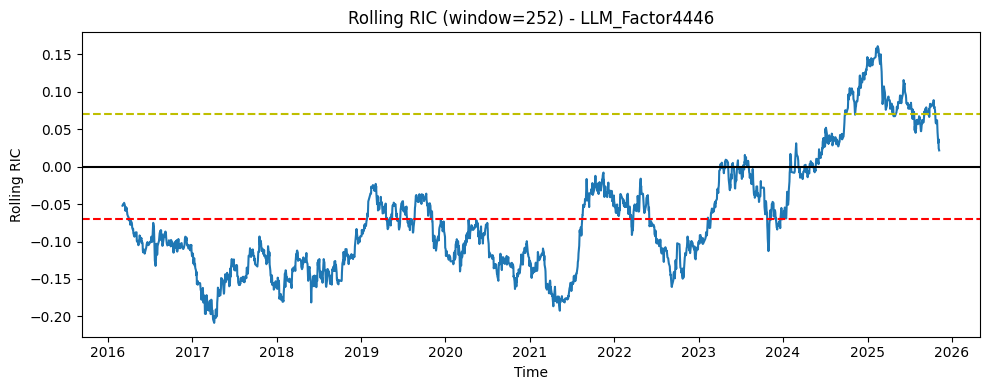

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/hpy/PycharmProjects/FAMA/RankIC/factor_rolling_ric.csv", parse_dates=["time"])

target_factor = "LLM_Factor4446"   # 你想看的因子名
sub = df[(df["unique_id"] == "000852.SH") & (df["factor_tag"] == target_factor)].copy()

sub = sub.sort_values("time")

plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["rolling_ric"])
plt.axhline(0, linestyle="-", color="k")
plt.axhline(0.07, linestyle="--", color="y" )
plt.axhline(-0.07, linestyle="--", color="r" )
plt.title(f"Rolling RIC (window={sub['window_size'].iloc[0]}) - {target_factor}")
plt.xlabel("Time")
plt.ylabel("Rolling RIC")
plt.tight_layout()
plt.show()


In [72]:
import pandas as pd
from pathlib import Path

# 读取刚才保存的滚动 RIC 文件
path = Path("/Users/hpy/PycharmProjects/FAMA/RankIC/factor_rolling_ric.csv")
df = pd.read_csv(path, parse_dates=["time"])

# 如果未来有多资产，这里可以只看某个资产；现在你只有 000852.SH，可以不用筛
# df = df[df["unique_id"] == "000852.SH"].copy()

# 1. 以 factor_tag 为单位，计算：
#    - 绝对值大于 0.07 的占比
#    - 正向大于 0.07 的占比
#    - 负向小于 -0.07 的占比
group = df.groupby("factor_tag")["rolling_ric"]

frac_abs = group.apply(lambda x: (x.abs() > 0.08).mean())
frac_pos = group.apply(lambda x: (x > 0.07).mean())
frac_neg = group.apply(lambda x: (x < -0.07).mean())

# 2. 条件：有一半时间 |RIC| > 0.07
mask_half_abs = frac_abs >= 0.7

selected_factors = frac_abs[mask_half_abs].index.tolist()

print("满足『至少一半时间 |RIC| > 0.07』的因子数量：", len(selected_factors))
print("这些因子是：")
for name in selected_factors:
    print(name)

# 如果你想顺便看一下这些因子是偏正还是偏负，也可以打个小表：
summary = pd.DataFrame({
    "frac_abs>0.07": frac_abs,
    "frac_ric>0.07": frac_pos,
    "frac_ric<-0.07": frac_neg,
})
print("\n详细占比统计（只展示满足条件的因子）：")
print(summary.loc[selected_factors].sort_values("frac_abs>0.07", ascending=False))


满足『至少一半时间 |RIC| > 0.07』的因子数量： 34
这些因子是：
LLM_Factor10284
LLM_Factor1837
LLM_Factor2522
LLM_Factor2784
LLM_Factor3091
LLM_Factor3312
LLM_Factor3833
LLM_Factor4446
LLM_Factor4758
LLM_Factor4764
LLM_Factor5548
LLM_Factor592
LLM_Factor6503
LLM_Factor6526
LLM_Factor6666
LLM_Factor6821
LLM_Factor6825
LLM_Factor7121
LLM_Factor7132
LLM_Factor7695
LLM_Factor7847
LLM_Factor8085
LLM_Factor8112
LLM_Factor8132
LLM_Factor8262
LLM_Factor8274
LLM_Factor8282
LLM_Factor8659
LLM_Factor8842
LLM_Factor8844
LLM_Factor8901
LLM_Factor9140
LLM_Factor9718
alpha158_std10

详细占比统计（只展示满足条件的因子）：
                 frac_abs>0.07  frac_ric>0.07  frac_ric<-0.07
factor_tag                                                   
LLM_Factor2522        0.920502       0.940586        0.000000
LLM_Factor3091        0.835685       0.000000        0.860581
LLM_Factor6526        0.825146       0.846794        0.000000
LLM_Factor7695        0.815091       0.000000        0.860697
LLM_Factor7121        0.812395       0.000000        0.83